<a href="https://colab.research.google.com/github/saabrinazada-web/tax-filling-risk-analysis/blob/main/Tax_Filing_Compliance_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from io import StringIO

# Baca data
df = pd.read_csv('/content/drive/MyDrive/TaxInfo.csv', index_col=0)

# Cek shape
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nInfo dataset:")
print(df.info())

Shape: (1004, 10)
Columns: ['HHI', 'HHDL', 'Married', 'CollegGrads', 'AHHAge', 'Cars', 'Filed in 2017', 'Filed in 2016', 'Filed in 2015', 'PoliticalParty']

Info dataset:
<class 'pandas.core.frame.DataFrame'>
Index: 1004 entries, 1 to 1004
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   HHI             1004 non-null   int64 
 1   HHDL            1004 non-null   int64 
 2   Married         1004 non-null   int64 
 3   CollegGrads     1004 non-null   int64 
 4   AHHAge          1004 non-null   int64 
 5   Cars            1004 non-null   int64 
 6   Filed in 2017   1004 non-null   int64 
 7   Filed in 2016   1004 non-null   int64 
 8   Filed in 2015   1004 non-null   int64 
 9   PoliticalParty  1004 non-null   object
dtypes: int64(9), object(1)
memory usage: 86.3+ KB
None


In [ ]:
# Feature Engineering yang sesuai
df['Total_Filed'] = df['Filed in 2017'] + df['Filed in 2016'] + df['Filed in 2015']
df['Filing_Consistency'] = df['Total_Filed'] / 3  # ratio 0-1

# Compliance Status (konsisten filing)
df['Compliance_Status'] = np.where(df['Total_Filed'] == 3, 'Consistent',
                          np.where(df['Total_Filed'] == 0, 'Never Filed', 'Inconsistent'))

# High Risk (target)
df['High_Risk'] = np.where(df['Total_Filed'] <= 1, 1, 0)  # Filed 0 or 1 times = high risk

# DTI (Debt to Income ratio) - Hati-hati dengan negative HHDL
df['DTI'] = np.where(df['HHI'] > 0,
                     np.abs(df['HHDL']) / df['HHI'],
                     0)  # Handle negative HHDL as absolute value

# Income bracket
df['Income_Bracket'] = pd.cut(df['HHI'], bins=[0, 50000, 100000, 150000, 200000, np.inf],
                               labels=['Very Low', 'Low', 'Middle', 'High', 'Very High'])

# Education Level
df['Education_Level'] = df['CollegGrads'].map({
    0: 'No College',
    1: 'Some College',
    2: 'Bachelor',
    3: 'Master',
    4: 'PhD',
    5: 'Multiple Degrees'
})

# Age Group
df['Age_Group'] = pd.cut(df['AHHAge'], bins=[0, 30, 45, 60, 100],
                          labels=['Young', 'Early Career', 'Mid Career', 'Near Retirement'])

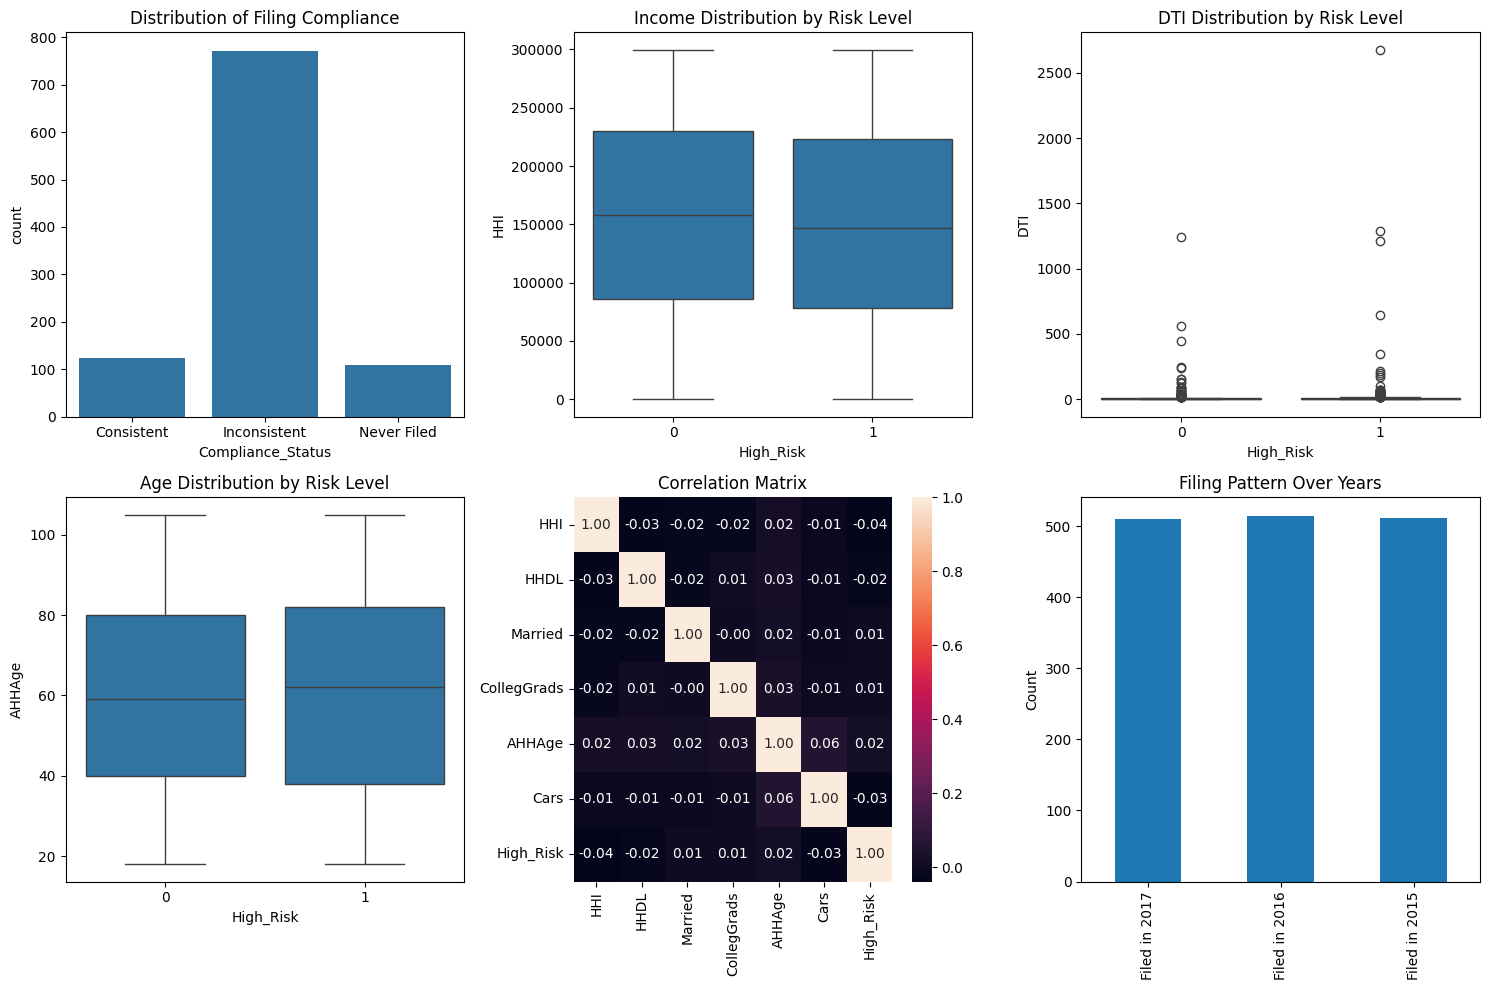

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi yang sesuai:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribusi Compliance Status
sns.countplot(data=df, x='Compliance_Status', ax=axes[0,0])
axes[0,0].set_title('Distribution of Filing Compliance')

# 2. Income vs Risk
sns.boxplot(data=df, x='High_Risk', y='HHI', ax=axes[0,1])
axes[0,1].set_title('Income Distribution by Risk Level')

# 3. DTI vs Risk
sns.boxplot(data=df, x='High_Risk', y='DTI', ax=axes[0,2])
axes[0,2].set_title('DTI Distribution by Risk Level')

# 4. Age vs Risk
sns.boxplot(data=df, x='High_Risk', y='AHHAge', ax=axes[1,0])
axes[1,0].set_title('Age Distribution by Risk Level')

# 5. Correlation Heatmap
numeric_cols = ['HHI', 'HHDL', 'Married', 'CollegGrads', 'AHHAge', 'Cars', 'High_Risk']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix')

# 6. Filing Pattern
filing_pattern = df[['Filed in 2017', 'Filed in 2016', 'Filed in 2015']].sum()
filing_pattern.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Filing Pattern Over Years')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Pilih features untuk model
features = ['HHI', 'DTI', 'AHHAge', 'Married', 'CollegGrads', 'Cars']
X = df[features]
y = df['High_Risk']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Model Performance:")
print(classification_report(y_test, y_pred))

# Odds Ratio
odds_ratio = np.exp(model.coef_[0])
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': model.coef_[0],
    'odds_ratio': odds_ratio
}).sort_values('odds_ratio', ascending=False)

print("\nFeature Importance (Odds Ratio):")
print(feature_importance)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

Model Performance:
              precision    recall  f1-score   support

           0       0.47      0.72      0.57        97
           1       0.48      0.24      0.32       104

    accuracy                           0.47       201
   macro avg       0.48      0.48      0.44       201
weighted avg       0.48      0.47      0.44       201


Feature Importance (Odds Ratio):
       feature  coefficient  odds_ratio
1          DTI     0.138333    1.148358
2       AHHAge     0.045263    1.046303
4  CollegGrads     0.017280    1.017431
3      Married     0.013175    1.013262
0          HHI    -0.048844    0.952330
5         Cars    -0.110077    0.895765


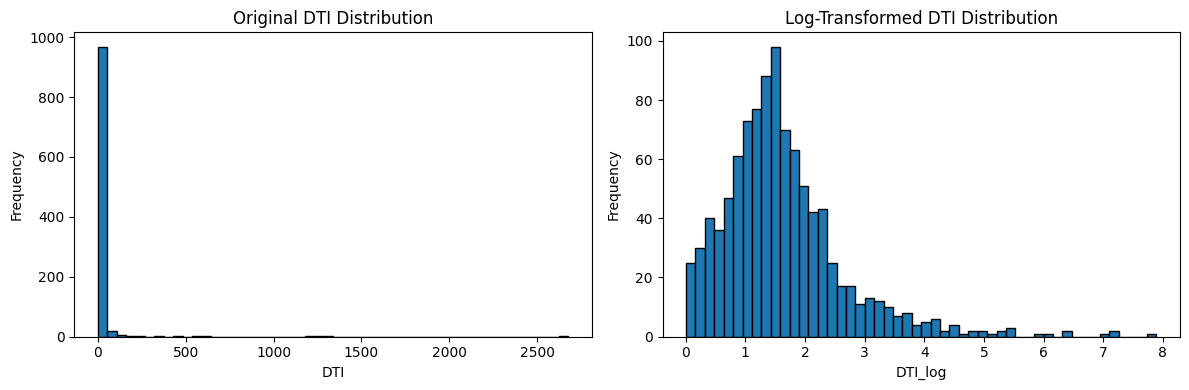

DTI skewness original: 16.71
DTI_log skewness: 1.72

MODEL PERFORMANCE WITH CLASS BALANCING

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.48      0.51       104
           1       0.50      0.57      0.53        97

    accuracy                           0.52       201
   macro avg       0.52      0.52      0.52       201
weighted avg       0.52      0.52      0.52       201

ROC-AUC Score: 0.524

Confusion Matrix:
[[50 54]
 [42 55]]

FEATURE IMPORTANCE (with Class Balancing & Log DTI)
    feature  coefficient  odds_ratio
CollegGrads     0.040866    1.041712
     AHHAge     0.024266    1.024562
    Married     0.019310    1.019497
    DTI_log    -0.004477    0.995533
        HHI    -0.063943    0.938059
       Cars    -0.069429    0.932927


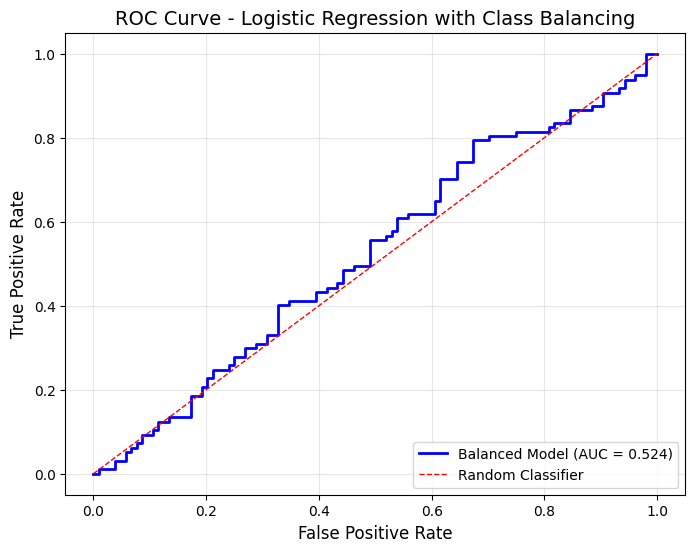


ROC-AUC without balancing: 0.523
ROC-AUC with balancing: 0.524
Improvement: 0.001

DISTRIBUSI HIGH_RISK
High_Risk
0    517
1    487
Name: count, dtype: int64

Persentase High Risk: 48.5%

ANALISIS PER SEGMEN

Risk Rate by Income Quintile:
HHI
(-114.515, 60088.0]     0.475676
(60088.0, 119991.0]     0.566502
(119991.0, 179894.0]    0.475000
(179894.0, 239797.0]    0.449761
(239797.0, 299700.0]    0.458937
Name: High_Risk, dtype: float64

Risk Rate by Age Group:
AHHAge
<30      0.521429
30-45    0.424731
45-60    0.464088
>60      0.510297
Name: High_Risk, dtype: float64

Risk Rate by DTI Quartile:
DTI_log
Low DTI        0.482072
Medium-Low     0.454183
Medium-High    0.470120
High DTI       0.533865
Name: High_Risk, dtype: float64


/tmp/ipython-input-2464502171.py:120: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_income = df.groupby(income_segments)['High_Risk'].mean()
/tmp/ipython-input-2464502171.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_age = df.groupby(age_segments)['High_Risk'].mean()
/tmp/ipython-input-2464502171.py:132: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_by_dti = df.groupby(dti_segments)['High_Ris

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Load data
df = pd.read_csv('/content/drive/MyDrive/TaxInfo.csv', index_col=0)

# Feature Engineering
df['Total_Filed'] = df['Filed in 2017'] + df['Filed in 2016'] + df['Filed in 2015']
df['High_Risk'] = np.where(df['Total_Filed'] <= 1, 1, 0)  # Filed 0 or 1 times = high risk
df['DTI'] = np.where(df['HHI'] > 0, np.abs(df['HHDL']) / df['HHI'], 0)

# STEP 1 - Transform DTI
df['DTI_log'] = np.log1p(df['DTI'])

# Cek distribusi sebelum dan sesudah transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['DTI'], bins=50, edgecolor='black')
axes[0].set_title('Original DTI Distribution')
axes[0].set_xlabel('DTI')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['DTI_log'], bins=50, edgecolor='black')
axes[1].set_title('Log-Transformed DTI Distribution')
axes[1].set_xlabel('DTI_log')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"DTI skewness original: {df['DTI'].skew():.2f}")
print(f"DTI_log skewness: {df['DTI_log'].skew():.2f}")

# STEP 2-4 - Model dengan fitur yang sudah ditransform
X = df[["HHI", "DTI_log", "AHHAge", "Married", "CollegGrads", "Cars"]]
y = df["High_Risk"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model dengan class balancing
model_balanced = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = model_balanced.predict(X_test_scaled)
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

# STEP 5 - Evaluation
print("\n" + "="*60)
print("MODEL PERFORMANCE WITH CLASS BALANCING")
print("="*60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_balanced):.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

# Feature Importance dengan model balanced
odds_ratio_balanced = np.exp(model_balanced.coef_[0])
feature_importance_balanced = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model_balanced.coef_[0],
    'odds_ratio': odds_ratio_balanced
}).sort_values('odds_ratio', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (with Class Balancing & Log DTI)")
print("="*60)
print(feature_importance_balanced.to_string(index=False))

# STEP 6 - ROC Curve
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_balanced)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bal, tpr_bal, 'b-', linewidth=2, label=f'Balanced Model (AUC = {roc_auc_score(y_test, y_prob_balanced):.3f})')
plt.plot([0,1], [0,1], 'r--', linewidth=1, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve - Logistic Regression with Class Balancing", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# Bandingkan dengan model tanpa balancing
model_unbalanced = LogisticRegression(class_weight=None, random_state=42, max_iter=1000)
model_unbalanced.fit(X_train_scaled, y_train)
y_prob_unbalanced = model_unbalanced.predict_proba(X_test_scaled)[:, 1]
roc_auc_unbalanced = roc_auc_score(y_test, y_prob_unbalanced)

print(f"\nROC-AUC without balancing: {roc_auc_unbalanced:.3f}")
print(f"ROC-AUC with balancing: {roc_auc_score(y_test, y_prob_balanced):.3f}")
print(f"Improvement: {(roc_auc_score(y_test, y_prob_balanced) - roc_auc_unbalanced):.3f}")

# Analisis distribusi High_Risk
print("\n" + "="*60)
print("DISTRIBUSI HIGH_RISK")
print("="*60)
print(df['High_Risk'].value_counts())
print(f"\nPersentase High Risk: {df['High_Risk'].mean()*100:.1f}%")

# Analisis per segmen
print("\n" + "="*60)
print("ANALISIS PER SEGMEN")
print("="*60)

# Income segments
income_segments = pd.cut(df['HHI'], bins=5)
risk_by_income = df.groupby(income_segments)['High_Risk'].mean()
print("\nRisk Rate by Income Quintile:")
print(risk_by_income)

# Age segments
age_segments = pd.cut(df['AHHAge'], bins=[0, 30, 45, 60, 100], labels=['<30', '30-45', '45-60', '>60'])
risk_by_age = df.groupby(age_segments)['High_Risk'].mean()
print("\nRisk Rate by Age Group:")
print(risk_by_age)

# DTI segments (log)
dti_segments = pd.qcut(df['DTI_log'], q=4, labels=['Low DTI', 'Medium-Low', 'Medium-High', 'High DTI'])
risk_by_dti = df.groupby(dti_segments)['High_Risk'].mean()
print("\nRisk Rate by DTI Quartile:")
print(risk_by_dti)